# explororation 14 : 트랜스포머로 만드는 대화형 챗봇

**루브릭 1. 한국어 전처리를 통해 학습 데이터셋을 구축하였다.**  
공백과 특수문자 처리, 토크나이징, 병렬데이터 구축의 과정이 적절히 진행되었다.

-> 

**루브릭 2.  트랜스포머 모델을 구현하여 한국어 챗봇 모델 학습을 정상적으로 진행하였다.**  
구현한 트랜스포머 모델이 한국어 병렬 데이터 학습 시 안정적으로 수렴하였다.

-> 

**루브릭 3. 한국어 입력문장에 대해 한국어로 답변하는 함수를 구현하였다.**  
한국어 입력문장에 맥락에 맞는 한국어로 답변을 리턴하였다.

-> 

# 1. Transformer에 대한 이해

## 1.1. positional encoding에 대한 이해 시도

Q1. 한 문장에 같은 단어 A가 여러 번 등장하였다고 가정해보겠습니다. 임베딩 문장 행렬에 포지셔널 인코딩을 해주었을 때와 해주지 않았을 때, 트랜스포머가 임베딩 문장 행렬 내의 다수의 A 단어 벡터로부터 얻을 수 있는 정보의 차이는 어떤 것이 있을까요?


제가 이해하기로는 다음과 같습니다.
한 문장에 있는 같은 단어들 A_1, A_2에 대하여 위치값 pos이 서로 다를 것입니다. pos/10000^{2i/d_model}의 값이 매우 작다고 가정할 수 있을 것이므로 (<pi/4) 위치값 pos에 대하여 벡터 PE(pos_1, ·)와 PE(pos_2, ·)는 서로 다를 것입니다. A_1과 A_2의 벡터를 서로 빼면 PE(pos_1,·)와 PE(pos_2,·)의 차가 될 것입니다. 결국, 주기가 서로 다른 사인함수와 코사인함수에 대하여 일정한 간격을 두고 그 값들(의 차를)을 알 수 있을 것입니다. 이를 통해서 두 pos의 값을 얻어낼 수 있다는 것 같은데 잘 모르겠습니다.

## 1.2. self-attention의 구조(행렬의 모양을 중심으로)

Vanilla transformer
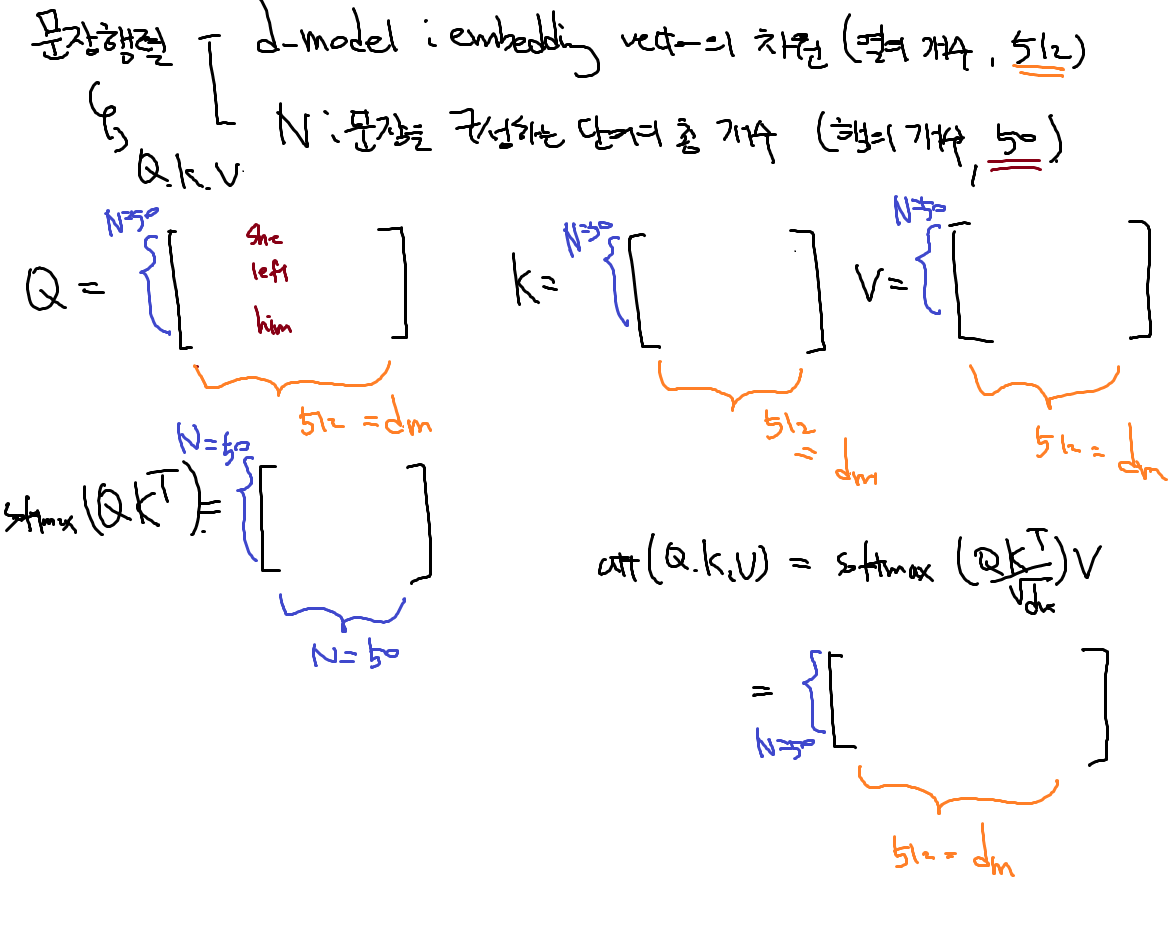

multihead transformer
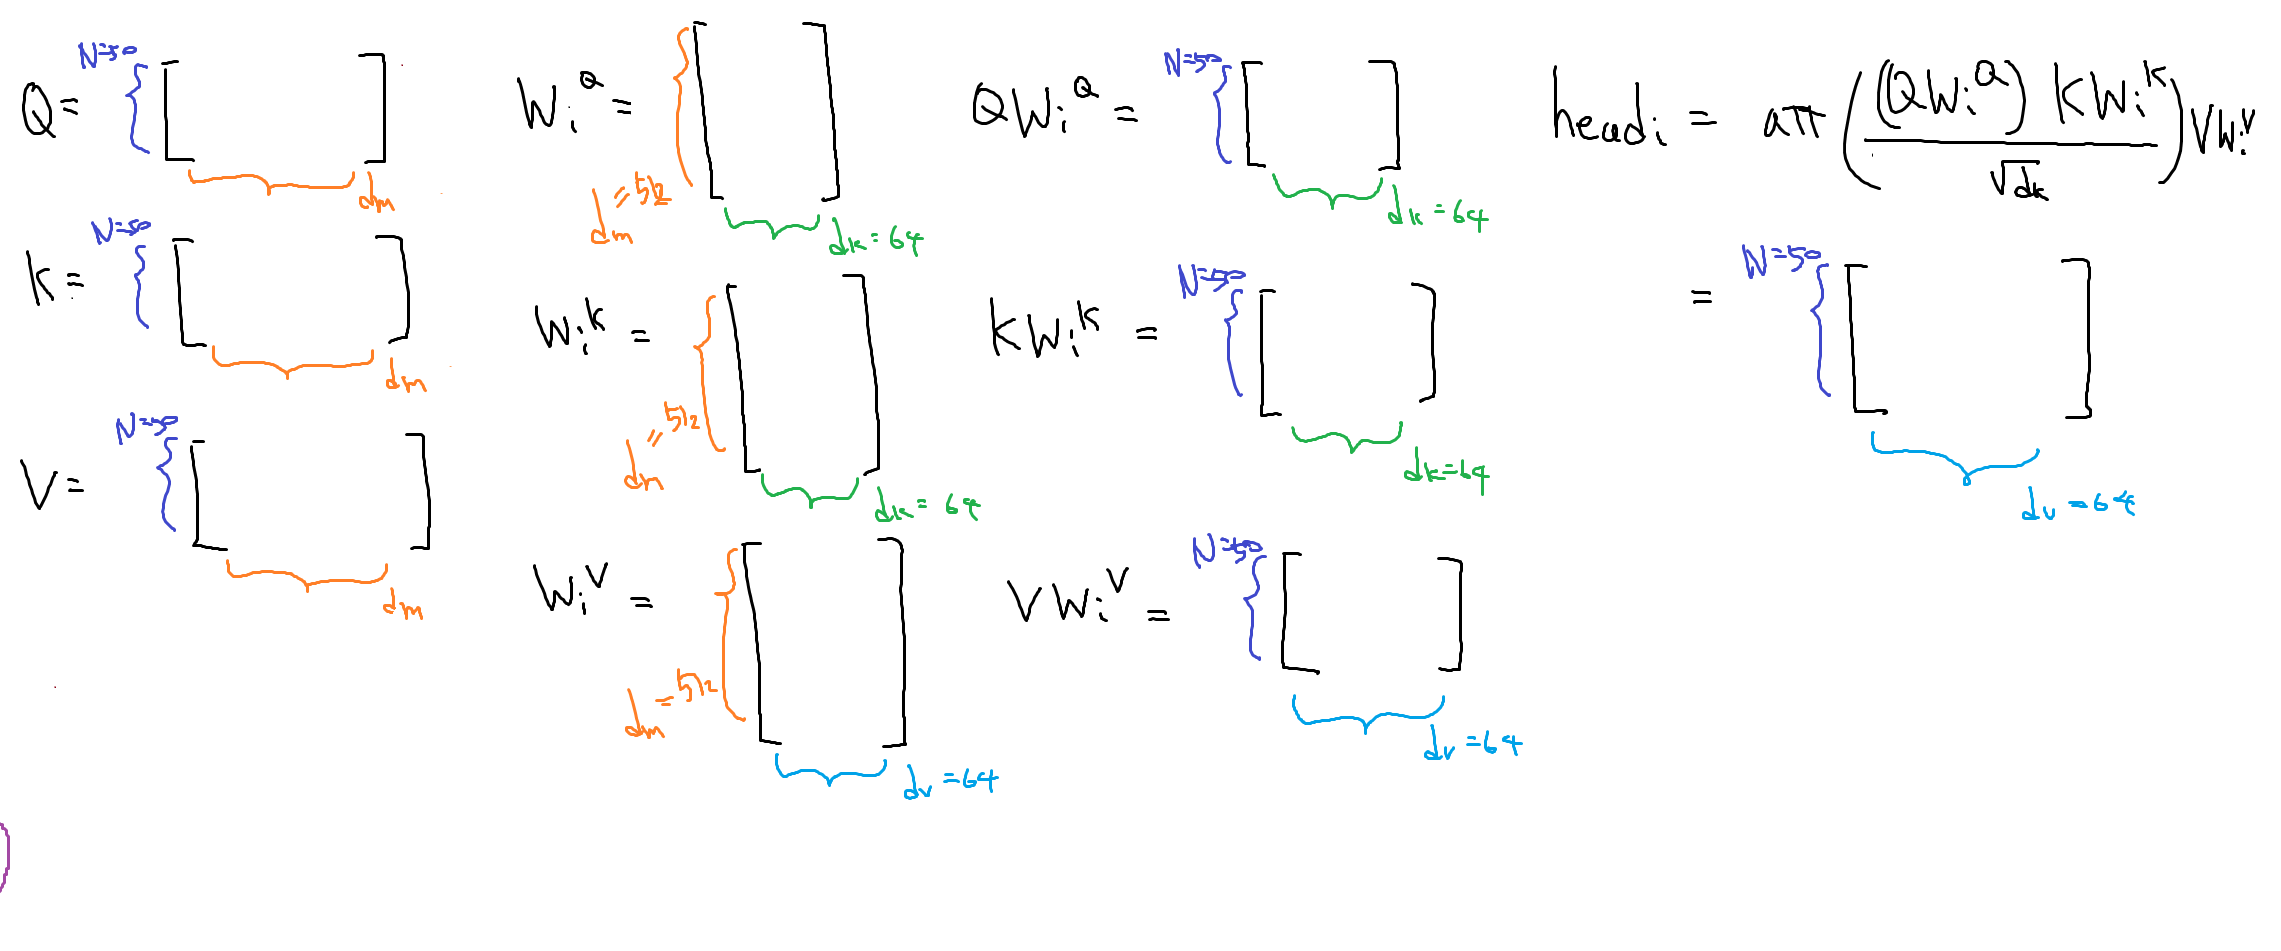

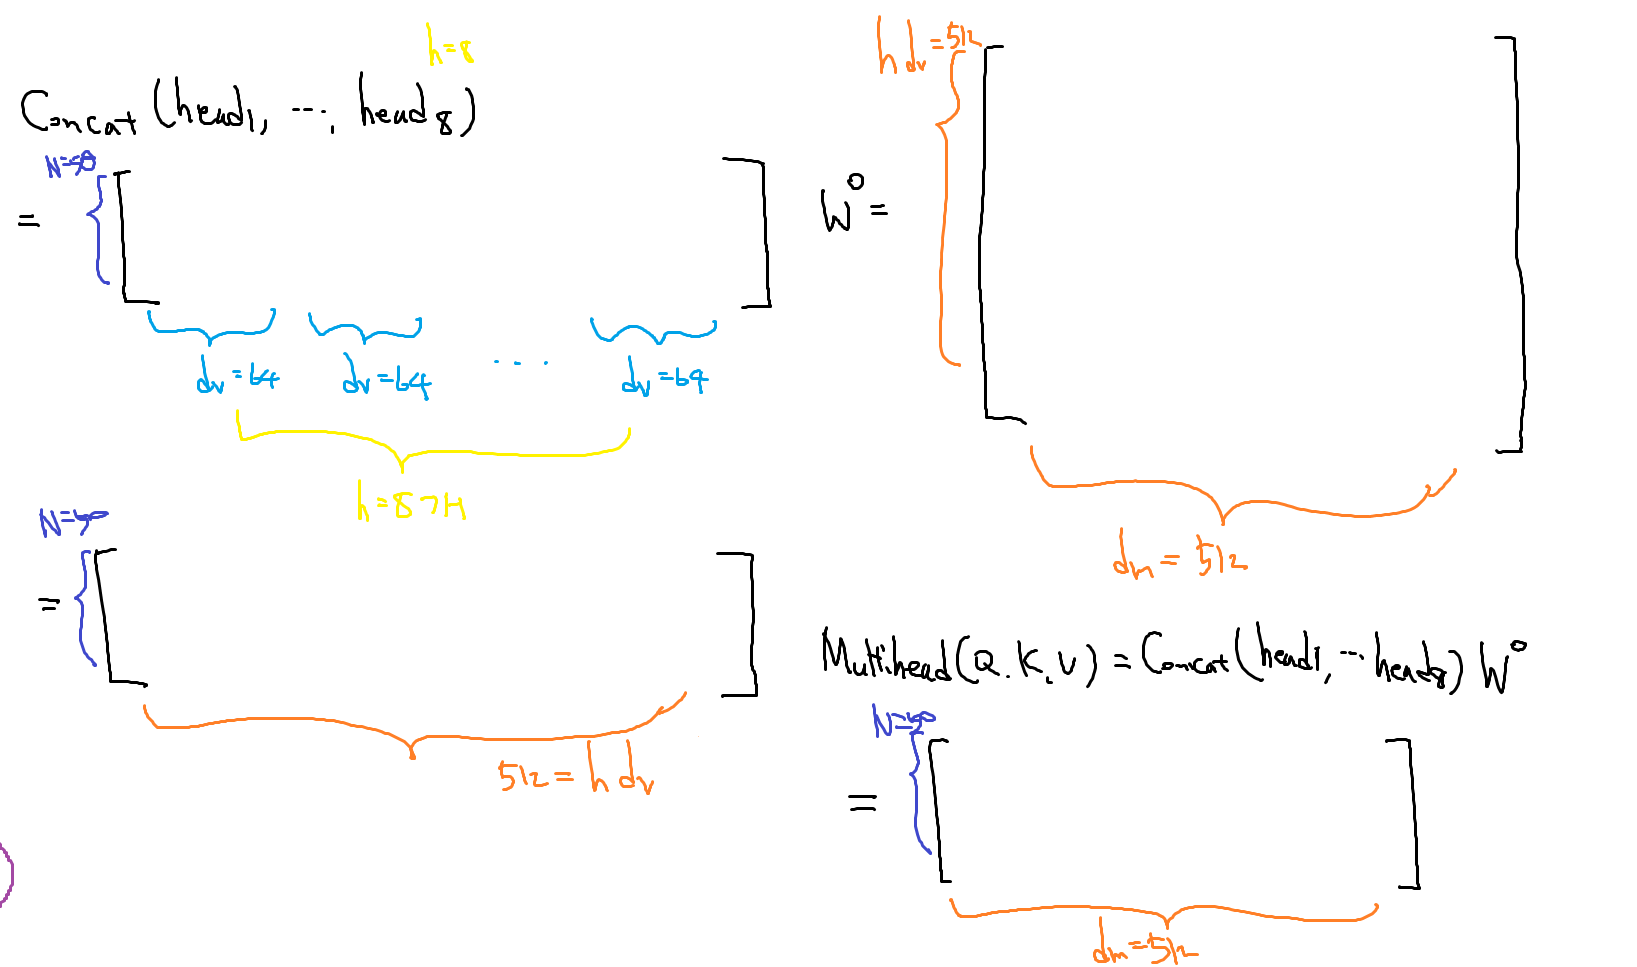

## 1.3. 논문 요약 : [Attention is all you need](https://arxiv.org/abs/1706.03762)


### 1. Introduction
RNN 구조(특히 LSTM, GRU)는 sequence modeling과 transduction problems(e.g. language modeling, machine translation)에서 표준적인 구조로 확립되었다.

recurrent model은 입력 수열과 출력 수열 사이의 단계를 분해(factor)하고, 그 과정에서 hidden state vector를 사용한다. 이러한 순차적 구조(inherently sequential nature)는 아키텍쳐로 하여금 학습 시의 병렬화를 불가능하게 한다(preclude parallelization). 최근에는 분해방법(factorization trick)을 통해 이를 해결하는 노력이 있기는 해왔지만, 여전히 한계는 존재한다.

한편, 어텐션(attention mechanism)은 sequence modeling이나 transduction model에서 상당한 성과를 보이고 있다. LSTM에서 hidden state vector를 통해 장기 기억을 보존하려 했다면, attention mechanism에서는 입력과 출력의 길이에 상관없이 의존성을 고려할 수 있다. (allowing modeling of dependencies without regard to their distance in the input or output sequences). 이러한 attention 기술은 RNN과도 접목되기도 한다.

이 논문에서는 transformer라는 아키텍쳐를 제안하는데, 이것은 RNN의 구조를 피하고 (eschewing recurrence) 온전히 attention mechanism에만 의존하여 global dependency를 얻고자 하였다.

### 2. Background (간략하게 기술)
GPU를 사용해 sequential computation의 하중을 줄이려는 노력이 있어왔다.

self attention은 intra-attention이로고도 불리는데, 어떤 수열(sequence)의 서로 다른 위치들을 연관시켜서 그 수열의 표현(representation)을 잘 계산할 수 있게 한다. reading comprehension, abstractive summaraization, textual entailment 등에서 그 효과가 입증됐다.

(end-to-end memory network에 대한 설명)

이러한 것들을 통해 보면 transformer의 의의는 다음과 같다. transformer는 (RNN이나 CNN적인 구조 없이) self attention에만 의존하여 입력과 출력의 표현을 계산하는 최초의 모델이다.

### 3. Model Architecture

일반적으로 encoder-decoder 구조는 널리 쓰인다. 특히 neural sequence transduction model에서 많이 쓰인다. encoder는 입력 x=(x_1, x_2,\cdots, x_n)을 continuous representation z=(z_1, z_2, \cdots, z_n)으로 맵핑시킨다. z는 latent vector 혹은 code라고 불려도 될 것 같고, 그러니까 encoder는 '암호화'의 역할을 수행하여 주어진 input sequence를 암호벡터로서 저장하는 것이다. RNN 기반의 seq2seq에서는 단순히 마지막 timestep의 hidden state vector를 z로 놓았다. attention과 RNN 기반의 seq2seq에서는 각 timestep의 hidden state vector를 attention value들과 일차결합(linear combination)하여 그것을 z로 놓았었다. 반면 decoder는 latent z를 수열 y=(y_1, y_2, \cdots, y_n)로 맵핑시키는데, 각 성분마다 하나씩 순차적으로 생성한다. (one element at a time)

transformer는 encoder와 decoder에서 (1) stacked self-attention, (2) pointwise connected layer, (3) fully conected layer 등을 사용한다. (아래 그림)

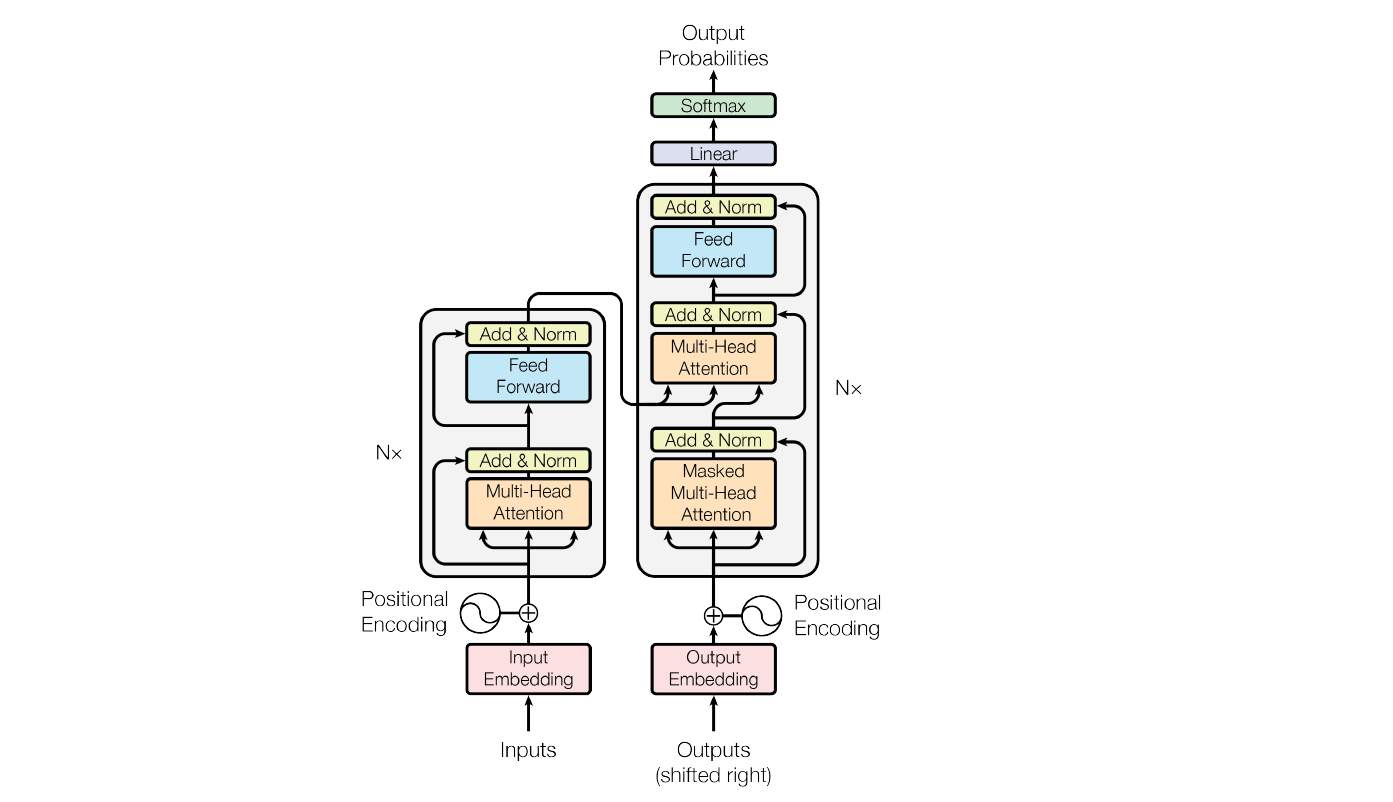



# 2. 트랜스포머로 만드는 대화형 챗봇

## 2.1. 데이터 수집하기

### 2.1.1. 모듈 불러오기

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import tensorflow_datasets as tfds

import os, re, time
import urllib.request

### 2.1.2. 데이터 불러오기

In [4]:
# 송영숙님의 데이터를 불러왔다.
# 출처 : https://github.com/songys/Chatbot_data/blob/master/ChatbotData.csv
# 해당 파일을 raw 형식으로 보이게 하여 모두 선택하고 복사하여 메모장에 저장한 뒤
# 그 파일(.txt)을 csv 형태의 파일로 바꾸어서 이 ipynb파일 근처에 두었다.
# 그리고 dataframe 형태로 불러와 df라는 객체에 할당했다.
# 그런데 label이 뭘 의미하는지 모르겠다.
df = pd.read_csv('data/14/chatbot_korean_sys.csv')
df

,Q,A,label
0,12시 땡!,하루가 또 가네요.,0
1,1지망 학교 떨어졌어,위로해 드립니다.,0
2,3박4일 놀러가고 싶다,여행은 언제나 좋죠.,0
3,3박4일 정도 놀러가고 싶다,여행은 언제나 좋죠.,0
4,PPL 심하네,눈살이 찌푸려지죠.,0
...,...,...,...
11818,훔쳐보는 것도 눈치 보임.,티가 나니까 눈치가 보이는 거죠!,2
11819,훔쳐보는 것도 눈치 보임.,훔쳐보는 거 티나나봐요.,2
11820,흑기사 해주는 짝남.,설렜겠어요.,2
11821,힘든 연애 좋은 연애라는게 무슨 차이일까?,잘 헤어질 수 있는 사이 여부인 거 같아요.,2


In [5]:
# df는 총 11823개의 sample들로 이루어져 있다.
# 처음 두 개 column은 질문과 답에 해당하는 한국어 문장이다.
# 마지막 column은 아직 무얼 의미하는 지 모르겠다.
print(len(df))
print(df.shape)
print(type(df))

11823
(11823, 3)
<class 'pandas.core.frame.DataFrame'>


## 2.2. 데이터 전처리하기

### 2.2.1. 결측치 제거

In [6]:
# 결측치가 있는지 없는지 확인한다.
# 여기에서 결측치라 함은 pd.NA이나 np.nan 말고 또 있을까? 모르겠다.
# 결측치는 없다.
print(df.isna().sum())

Q        0
A        0
label    0
dtype: int64


### 2.2.2. 구두점에 대하여 띄어쓰기로 구분하기

In [47]:
print(list(df['Q'][:2]))
print(list(df['A'][:2]))

['12시 땡!', '1지망 학교 떨어졌어']
['하루가 또 가네요.', '위로해 드립니다.']


In [7]:
# df의 첫번째 열과 두번째 열을 전처리하여 questions와 answers에 할당한다.
# 여기에서 전처리라 함은, 구두점에 대하여 띄어쓰기를 하는 것만을 의미하는 것 같다.
# 사실 잘 모르겠다.
questions = []
for sentence in df['Q']:
    # 구두점에 대해서 띄어쓰기
    # ex) 12시 땡! -> 12시 땡 !
    sentence = re.sub(r"([?.!,])", r" \1 ", sentence)
    sentence = sentence.strip()
    questions.append(sentence)

In [8]:
answers = []
for sentence in df['A']:
    # 구두점에 대해서 띄어쓰기
    # ex) 12시 땡! -> 12시 땡 !
    sentence = re.sub(r"([?.!,])", r" \1 ", sentence)
    sentence = sentence.strip()
    answers.append(sentence)

In [48]:
print(questions[:2])
print(answers[:2])

['12시 땡 !', '1지망 학교 떨어졌어']
['하루가 또 가네요 .', '위로해 드립니다 .']


## 2.3. SubwordTextEncoder 사용하기

### 2.3.1. `tokenizer` 생성

In [12]:
# SubwordTextEncoder를 사용하여 tokenizer를 만든다.
# tfds : tensorflow_datasets (tfds) defines a collection of datasets ready-to-use with TensorFlow.
# tfds_deprecated : Deprecated symbols.
# tfds.deprecated.text : Text utilities.
# tfds.deprecated.text.SubwordTextEncoder : Invertible TextEncoder using word pieces with a byte-level fallback.
#
# tfds.deprecated.text에 또다른 subclass들도 있다. 그것들은 다음과 같다.
# ByteTextEncoder, # TextEncoder, TokenTextEncoder, Tokenizer

tokenizer = tfds.deprecated.text.SubwordTextEncoder.build_from_corpus(questions + answers, target_vocab_size=2**13)

### 2.3.2. `tokenizer` 뜯어보기

In [56]:
# tokenizer는 여러 메소드들을 가지고 있다. 그것은 dir(tokenizer)를 통해 조회할 수 있다.
# 그 중 이번 노드와 관련 있어 보이는 것은 (1) vocab_size, (2) subwords, (3) encode, (4) decode의 네 개 정도인 것 같다.
dir(tokenizer)[-6:]

['decode',
 'encode',
 'load_from_file',
 'save_to_file',
 'subwords',
 'vocab_size']

In [53]:
# (1) vocab_size : str
# tokenizer란 하나의 사전(vocabulary)을 의미한다.
# 다시 말해, 단어(str)와 숫자(int) 사이의 일대일대응을 의미한다.
# 총 8178개의 단어가 있고 각각의 단어들에 대응되는 8178개의 정수들 (0, 1, \cdots, 8177)이 있을 것이다.
tokenizer.vocab_size

8178

In [18]:
# (2) subwords : list
# subwords들의 집합으로 list 형식으로 나열되었다.
# 한가지 이해되지 않는 점은, subwords의 길이가 7921으로 8178보다 적다는 것이다.
print(type(tokenizer.subwords))
print(len(tokenizer.subwords))
print(tokenizer.subwords[:20])

<class 'list'>
7921
[' .', ' ?', '거예요', '수_', '게_', '너무_', '더_', '거_', '좋아하는_', '는_', '이_', '을_', '잘_', '도_', ' .  ', '고_', '요', '것_', '많이_', '안_']


In [60]:
# (3) encode
# 문자열을 정수로 변환한다. 문자열은 하나의 subword여도 되지만, 여러 개의 subword가 이어져있어 하나의 문장이나 구를 구성하여도 된다.
# 아래는 문자열이 하나의 subword인 경우이다. 그 결과는 length가 1인 list로 나온다.
# (4) decode
# 정수를 문자열로 변환한다.
print(tokenizer.encode(' .'))
print(tokenizer.encode(' ?'))
print(tokenizer.encode('거예요'))
print(tokenizer.decode([1]))
print(tokenizer.decode([2]))
print(tokenizer.decode([3]))

[1]
[2]
[3]
 .
 ?
거예요


In [57]:
# 아래는 문자열이 하나의 subword가 아닌 경우, 즉 여러 개의 subword가 이어져있어 하나의 구를 구성하는 경우이다.
print(tokenizer.encode('단어장에 없는 문자'))

[596, 2551, 29, 119, 2087]


In [62]:
# subword는 1부터 시작하는 것처럼 보이지만, encode에 0을 넣어도 결과가 나오기는 한다.
# decode에 ''을 넣으면 빈 리스트가 생성된다.
print(tokenizer.decode([0]))
print(tokenizer.encode(''))


[]


In [43]:
# encode에 1-space, 2-space, 3-space를 넣었을 때의 결과이다.
# 3-space는 2-space와 1-space가 이어진 것으로 생각하는 모양이다.
print(tokenizer.encode(''))
print(tokenizer.encode(' '))
print(tokenizer.encode('  '))
print(tokenizer.encode('   '))

[]
[7954]
[2164]
[2164, 7954]


In [44]:
# encode에 period(.)을 여러 형태로 넣어 본 결과이다.
print(tokenizer.encode('.'))
print(tokenizer.encode(' '))
print(tokenizer.encode('. '))
print(tokenizer.encode(' .'))

[7968]
[7954]
[7968, 7954]
[1]


### 2.3.3. 시작토큰과 종료토큰 지정

In [68]:
tokenizer.encode(' .')

[1]

In [72]:
integers = []
for token in tokenizer.subwords:
    integers.append(tokenizer.encode(token))
integers = sorted(integers)
integers

[[1],
 [2],
 [3],
 [15],
 [17],
 [17, 303, 8017],
 [17, 1268, 8017],
 [17, 3952, 771, 8017],
 [17, 3952, 8017],
 [22],
 [25],
 [26],
 [26, 2181, 8017],
 [26, 8017],
 [32],
 [36],
 [36, 78, 8017],
 [36, 629, 8017],
 [36, 5594, 8017],
 [36, 8017],
 [37],
 [37, 174, 8017],
 [37, 8017],
 [38],
 [38, 8017],
 [41],
 [44],
 [47],
 [47, 78, 8017],
 [47, 111, 8017],
 [47, 117, 8017],
 [47, 221, 8017],
 [47, 307, 111, 8017],
 [47, 343, 8017],
 [47, 364, 8017],
 [47, 621, 8017],
 [47, 743, 8017],
 [47, 876, 111, 8017],
 [47, 2398, 8017],
 [47, 2709, 1274, 8017],
 [47, 4799, 342, 8017],
 [47, 4799, 8017],
 [47, 5594, 8017],
 [47, 8017],
 [49],
 [50],
 [51],
 [51, 174, 8017],
 [51, 221, 8017],
 [51, 549, 8017],
 [51, 1451, 835, 8017],
 [51, 1451, 8017],
 [51, 1451, 8157, 8063, 8089, 8017],
 [51, 8017],
 [51, 8157, 8067, 8082, 4121, 8017],
 [51, 8158, 8091, 8070, 8017],
 [55],
 [55, 111, 8017],
 [55, 266, 8017],
 [55, 1833, 8017],
 [55, 8017],
 [59],
 [59, 47, 8017],
 [59, 174, 8017],
 [59, 203, 635

In [12]:
# 시작 토큰과 종료 토큰에 대한 정수 부여.
START_TOKEN, END_TOKEN = [tokenizer.vocab_size], [tokenizer.vocab_size + 1]

# 시작 토큰과 종료 토큰을 고려하여 단어 집합의 크기를 + 2
VOCAB_SIZE = tokenizer.vocab_size + 2

In [13]:
print('시작 토큰 번호 :',START_TOKEN)
print('종료 토큰 번호 :',END_TOKEN)
print('단어 집합의 크기 :',VOCAB_SIZE)

시작 토큰 번호 : [8178]
종료 토큰 번호 : [8179]
단어 집합의 크기 : 8180


In [22]:
print('임의의 질문 샘플을 정수 인코딩 : {}'.format(tokenizer.encode(questions[20])))

임의의 질문 샘플을 정수 인코딩 : [5766, 611, 3509, 141, 685, 3747, 849]


In [24]:
tokenizer.encode("안녕, 그동안 잘 지냈나요?")

[907, 7966, 7954, 1932, 13, 3294, 847, 7985]

In [25]:
tokenizer.encode("나는 잘 지내고 있어요.")

[267, 13, 1617, 25, 7968]

In [26]:
questions[20]

'가스비 비싼데 감기 걸리겠어'

In [28]:
# 서브워드텍스트인코더 토크나이저의 .encode()와 .decode() 테스트해보기
# 임의의 입력 문장을 sample_string에 저장
sample_string = questions[20]

# encode() : 텍스트 시퀀스 --> 정수 시퀀스
tokenized_string = tokenizer.encode(sample_string)
print ('정수 인코딩 후의 문장 {}'.format(tokenized_string))

# decode() : 정수 시퀀스 --> 텍스트 시퀀스
original_string = tokenizer.decode(tokenized_string)
print ('기존 문장: {}'.format(original_string))

정수 인코딩 후의 문장 [5766, 611, 3509, 141, 685, 3747, 849]
기존 문장: 가스비 비싼데 감기 걸리겠어


In [29]:
# 각 정수는 각 단어와 어떻게 mapping되는지 병렬로 출력
# 서브워드텍스트인코더는 의미있는 단위의 서브워드로 토크나이징한다. 띄어쓰기 단위 X 형태소 분석 단위 X
for ts in tokenized_string:
  print ('{} ----> {}'.format(ts, tokenizer.decode([ts])))

5766 ----> 가스
611 ----> 비 
3509 ----> 비싼
141 ----> 데 
685 ----> 감기 
3747 ----> 걸리
849 ----> 겠어


In [30]:
tokenizer.decode([907, 7966, 7954, 1932, 13, 3294, 847, 7985])

'안녕, 그동안 잘 지냈나요?'

In [31]:
tokenizer.decode([267, 13, 1617, 25, 7968])

'나는 잘 지내고 있어요.'

In [32]:
# 최대 길이를 40으로 정의
MAX_LENGTH = 40

# 토큰화 / 정수 인코딩 / 시작 토큰과 종료 토큰 추가 / 패딩
def tokenize_and_filter(inputs, outputs):
  tokenized_inputs, tokenized_outputs = [], []

  for (sentence1, sentence2) in zip(inputs, outputs):
    # encode(토큰화 + 정수 인코딩), 시작 토큰과 종료 토큰 추가
    sentence1 = START_TOKEN + tokenizer.encode(sentence1) + END_TOKEN
    sentence2 = START_TOKEN + tokenizer.encode(sentence2) + END_TOKEN

    tokenized_inputs.append(sentence1)
    tokenized_outputs.append(sentence2)

  # 패딩
  tokenized_inputs = tf.keras.preprocessing.sequence.pad_sequences(
      tokenized_inputs, maxlen=MAX_LENGTH, padding='post')
  tokenized_outputs = tf.keras.preprocessing.sequence.pad_sequences(
      tokenized_outputs, maxlen=MAX_LENGTH, padding='post')

  return tokenized_inputs, tokenized_outputs


In [43]:
tokenized_inputs = []
tokenized_outputs = []

In [68]:
print(type(questions))
print(len(questions))
print(len(questions[0]))
print(len(questions[1]))
print(len(questions[2]))
print(questions[:2])

<class 'list'>
11823
7
11
12
['12시 땡 !', '1지망 학교 떨어졌어']


In [49]:
print(type(answers))
print(len(answers))
print(len(answers[0]))
print(len(answers[1]))
print(len(answers[2]))
print(answers[:2])

<class 'list'>
11823
11
10
12
['하루가 또 가네요 .', '위로해 드립니다 .']


In [48]:
tokenized_inputs =[]
tokenized_outputs = []

In [56]:
QA = [(s1, s2) for s1, s2 in zip(questions,answers)]
QA[:2]

[('12시 땡 !', '하루가 또 가네요 .'), ('1지망 학교 떨어졌어', '위로해 드립니다 .')]

In [63]:
q0, a0 = QA[0]
print(q0)
print(a0)
print(tokenizer.encode(q0))
print(tokenizer.encode(a0))
print(START_TOKEN + tokenizer.encode(q0) + END_TOKEN)
print(START_TOKEN + tokenizer.encode(a0) + END_TOKEN)

12시 땡 !
하루가 또 가네요 .
[7915, 4207, 3060, 41]
[3844, 74, 7894, 1]
[8178, 7915, 4207, 3060, 41, 8179]
[8178, 3844, 74, 7894, 1, 8179]


In [64]:
q1, a1 = QA[1]
print(q1)
print(a1)
print(tokenizer.encode(q1))
print(tokenizer.encode(a1))
print(START_TOKEN + tokenizer.encode(q1) + END_TOKEN)
print(START_TOKEN + tokenizer.encode(a1) + END_TOKEN)

1지망 학교 떨어졌어
위로해 드립니다 .
[7971, 47, 919, 7954, 998, 1716]
[1830, 5502, 1]
[8178, 7971, 47, 919, 7954, 998, 1716, 8179]
[8178, 1830, 5502, 1, 8179]


In [79]:
print(type(questions))
print(len(questions))
print(len(questions[0]))
print(len(questions[1]))
print(questions[:2])

<class 'list'>
11823
7
11
['12시 땡 !', '1지망 학교 떨어졌어']


In [77]:
questions_tokenized = [START_TOKEN + tokenizer.encode(q) + END_TOKEN for q in questions]
answers_tokenized = [START_TOKEN + tokenizer.encode(a) + END_TOKEN for a in answers]

In [80]:
print(type(questions_tokenized))
print(len(questions_tokenized))
print(len(questions_tokenized[0]))
print(len(questions_tokenized[1]))
print(questions_tokenized[:2])

<class 'list'>
11823
6
8
[[8178, 7915, 4207, 3060, 41, 8179], [8178, 7971, 47, 919, 7954, 998, 1716, 8179]]


In [78]:
questions_padded = tf.keras.preprocessing.sequence.pad_sequences(questions_tokenized,
                   maxlen=MAX_LENGTH, padding='post')
answers_padded = tf.keras.preprocessing.sequence.pad_sequences(answers_tokenized,
                   maxlen=MAX_LENGTH, padding='post')

In [82]:
print(type(questions_padded))
print(questions_padded.shape)
print(len(questions_padded[0]))
print(len(questions_padded[1]))
print(questions_padded[:2])

<class 'numpy.ndarray'>
(11823, 40)
40
40
[[8178 7915 4207 3060   41 8179    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0]
 [8178 7971   47  919 7954  998 1716 8179    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0]]


In [83]:
print(type(answers_padded))
print(answers_padded.shape)
print(len(answers_padded[0]))
print(len(answers_padded[1]))
print(answers_padded[:2])

<class 'numpy.ndarray'>
(11823, 40)
40
40
[[8178 3844   74 7894    1 8179    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0]
 [8178 1830 5502    1 8179    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0]]


## 14-3

In [ ]:
import tensorflow as tf
import tensorflow_datasets as tfds
import os
import re
import numpy as np
import matplotlib.pyplot as plt
print("슝=3")

In [ ]:
# 포지셔널 인코딩 레이어
# positional encoding vector는 원래의 word vector에 더해지는 vector이다.
# 정확하게는, word vector 하나만 입력으로 들어가는 것이 아니고, 여러 개의 word vector,
# 즉 문장이 입력으로 들어가게 되므로 어떤 rank 2 tensor인 matrix가 입력값이 된다.
# 이때의 벡터들은 행벡터로 간주하므로, 이 matrix에서 행번호란 단어의 위치 (pos)를 의미하고
# 열번호란 해당 word vector의 성분 (i)을 의미한다.
# positional encoding 또한, 코드 상에서는 positional encoding vector로 입력되는 것이 아니라
# positional encoding matrix로 들어간다. 어차피 최대 문장의 길이(N)와
# embedding vector의 차원(d_model)은 결정되어 있기 때문에, N과 d_model을 가지고
# positional eocnding matrix를 만들어놓아도 상관없다. 이렇게 만들어놓은 positional encoding matrix는
# 길이가 N 이하이고 word embedding의 차원이 d_model인 임의의 문장에
# 일괄적으로 적용시킬 수 있다.
class PositionalEncoding(tf.keras.layers.Layer):

  def __init__(self, position, d_model):
    super(PositionalEncoding, self).__init__()
    self.pos_encoding = self.positional_encoding(position, d_model)

  def get_angles(self, position, i, d_model):
    angles = 1 / tf.pow(10000, (2 * (i // 2)) / tf.cast(d_model, tf.float32))
    return position * angles

  def positional_encoding(self, position, d_model):
    # 각도 배열 생성
    angle_rads = self.get_angles(
        position=tf.range(position, dtype=tf.float32)[:, tf.newaxis],
        i=tf.range(d_model, dtype=tf.float32)[tf.newaxis, :],
        d_model=d_model)

    # 배열의 짝수 인덱스에는 sin 함수 적용
    sines = tf.math.sin(angle_rads[:, 0::2])
    # 배열의 홀수 인덱스에는 cosine 함수 적용
    cosines = tf.math.cos(angle_rads[:, 1::2])

    # sin과 cosine이 교차되도록 재배열
    pos_encoding = tf.stack([sines, cosines], axis=0)
    pos_encoding = tf.transpose(pos_encoding,[1, 2, 0]) 
    pos_encoding = tf.reshape(pos_encoding, [position, d_model])

    pos_encoding = pos_encoding[tf.newaxis, ...]
    return tf.cast(pos_encoding, tf.float32)

  def call(self, inputs):
    return inputs + self.pos_encoding[:, :tf.shape(inputs)[1], :]

print("슝=3")

In [ ]:
sample_pos_encoding = PositionalEncoding(50, 512)

plt.pcolormesh(sample_pos_encoding.pos_encoding.numpy()[0], cmap='RdBu')
plt.xlabel('Depth')
plt.xlim((0, 512))
plt.ylabel('Position')
plt.colorbar()
plt.show()

## 14-5

In [ ]:
# 스케일드 닷 프로덕트 어텐션 함수
def scaled_dot_product_attention(query, key, value, mask):
  # 어텐션 가중치는 Q와 K의 닷 프로덕트
  matmul_qk = tf.matmul(query, key, transpose_b=True)

  # 가중치를 정규화
  depth = tf.cast(tf.shape(key)[-1], tf.float32)
  logits = matmul_qk / tf.math.sqrt(depth)

  # 패딩에 마스크 추가
  if mask is not None:
    logits += (mask * -1e9)

  # softmax적용
  attention_weights = tf.nn.softmax(logits, axis=-1)

  # 최종 어텐션은 가중치와 V의 닷 프로덕트
  output = tf.matmul(attention_weights, value)
  return output

print("슝=3")

## 14-6

In [ ]:
class MultiHeadAttention(tf.keras.layers.Layer):

  def __init__(self, d_model, num_heads, name="multi_head_attention"):
    super(MultiHeadAttention, self).__init__(name=name)
    self.num_heads = num_heads
    self.d_model = d_model

    assert d_model % self.num_heads == 0

    self.depth = d_model // self.num_heads

    self.query_dense = tf.keras.layers.Dense(units=d_model)
    self.key_dense = tf.keras.layers.Dense(units=d_model)
    self.value_dense = tf.keras.layers.Dense(units=d_model)

    self.dense = tf.keras.layers.Dense(units=d_model)

  def split_heads(self, inputs, batch_size):
    inputs = tf.reshape(
        inputs, shape=(batch_size, -1, self.num_heads, self.depth))
    return tf.transpose(inputs, perm=[0, 2, 1, 3])

  def call(self, inputs):
    query, key, value, mask = inputs['query'], inputs['key'], inputs[
        'value'], inputs['mask']
    batch_size = tf.shape(query)[0]

    # Q, K, V에 각각 Dense를 적용합니다
    query = self.query_dense(query)
    key = self.key_dense(key)
    value = self.value_dense(value)

    # 병렬 연산을 위한 머리를 여러 개 만듭니다
    query = self.split_heads(query, batch_size)
    key = self.split_heads(key, batch_size)
    value = self.split_heads(value, batch_size)

    # 스케일드 닷 프로덕트 어텐션 함수
    scaled_attention = scaled_dot_product_attention(query, key, value, mask)

    scaled_attention = tf.transpose(scaled_attention, perm=[0, 2, 1, 3])

    # 어텐션 연산 후에 각 결과를 다시 연결(concatenate)합니다
    concat_attention = tf.reshape(scaled_attention,
                                  (batch_size, -1, self.d_model))

    # 최종 결과에도 Dense를 한 번 더 적용합니다
    outputs = self.dense(concat_attention)

    return outputs
print("슝=3")

## 14-7

In [ ]:
def create_padding_mask(x):
  mask = tf.cast(tf.math.equal(x, 0), tf.float32)
  # (batch_size, 1, 1, sequence length)
  return mask[:, tf.newaxis, tf.newaxis, :]
print("슝=3")

In [ ]:
print(create_padding_mask(tf.constant([[1, 2, 0, 3, 0], [0, 0, 0, 4, 5]])))

In [ ]:
def create_look_ahead_mask(x):
  seq_len = tf.shape(x)[1]
  look_ahead_mask = 1 - tf.linalg.band_part(tf.ones((seq_len, seq_len)), -1, 0)
  padding_mask = create_padding_mask(x)
  return tf.maximum(look_ahead_mask, padding_mask)
print("슝=3")

In [ ]:
print(create_look_ahead_mask(tf.constant([[1, 2, 3, 4, 5]])))

In [ ]:
print(create_look_ahead_mask(tf.constant([[0, 5, 1, 5, 5]])))

## 14-8

In [ ]:
# 인코더 하나의 레이어를 함수로 구현.
# 이 하나의 레이어 안에는 두 개의 서브 레이어가 존재합니다.
def encoder_layer(units, d_model, num_heads, dropout, name="encoder_layer"):
  inputs = tf.keras.Input(shape=(None, d_model), name="inputs")

  # 패딩 마스크 사용
  padding_mask = tf.keras.Input(shape=(1, 1, None), name="padding_mask")

  # 첫 번째 서브 레이어 : 멀티 헤드 어텐션 수행 (셀프 어텐션)
  attention = MultiHeadAttention(
      d_model, num_heads, name="attention")({
          'query': inputs,
          'key': inputs,
          'value': inputs,
          'mask': padding_mask
      })

  # 어텐션의 결과는 Dropout과 Layer Normalization이라는 훈련을 돕는 테크닉을 수행
  attention = tf.keras.layers.Dropout(rate=dropout)(attention)
  attention = tf.keras.layers.LayerNormalization(
      epsilon=1e-6)(inputs + attention)

  # 두 번째 서브 레이어 : 2개의 완전연결층
  outputs = tf.keras.layers.Dense(units=units, activation='relu')(attention)
  outputs = tf.keras.layers.Dense(units=d_model)(outputs)

  # 완전연결층의 결과는 Dropout과 LayerNormalization이라는 훈련을 돕는 테크닉을 수행
  outputs = tf.keras.layers.Dropout(rate=dropout)(outputs)
  outputs = tf.keras.layers.LayerNormalization(
      epsilon=1e-6)(attention + outputs)

  return tf.keras.Model(
      inputs=[inputs, padding_mask], outputs=outputs, name=name)
print("슝=3")

In [ ]:
def encoder(vocab_size,
            num_layers,
            units,
            d_model,
            num_heads,
            dropout,
            name="encoder"):
  inputs = tf.keras.Input(shape=(None,), name="inputs")

  # 패딩 마스크 사용
  padding_mask = tf.keras.Input(shape=(1, 1, None), name="padding_mask")

  # 임베딩 레이어
  embeddings = tf.keras.layers.Embedding(vocab_size, d_model)(inputs)
  embeddings *= tf.math.sqrt(tf.cast(d_model, tf.float32))

  # 포지셔널 인코딩
  embeddings = PositionalEncoding(vocab_size, d_model)(embeddings)

  outputs = tf.keras.layers.Dropout(rate=dropout)(embeddings)

  # num_layers만큼 쌓아올린 인코더의 층.
  for i in range(num_layers):
    outputs = encoder_layer(
        units=units,
        d_model=d_model,
        num_heads=num_heads,
        dropout=dropout,
        name="encoder_layer_{}".format(i),
    )([outputs, padding_mask])

  return tf.keras.Model(
      inputs=[inputs, padding_mask], outputs=outputs, name=name)
print("슝=3")

## 14-9

In [ ]:
# 디코더 하나의 레이어를 함수로 구현.
# 이 하나의 레이어 안에는 세 개의 서브 레이어가 존재합니다.
def decoder_layer(units, d_model, num_heads, dropout, name="decoder_layer"):
  inputs = tf.keras.Input(shape=(None, d_model), name="inputs")
  enc_outputs = tf.keras.Input(shape=(None, d_model), name="encoder_outputs")
  look_ahead_mask = tf.keras.Input(
      shape=(1, None, None), name="look_ahead_mask")
  padding_mask = tf.keras.Input(shape=(1, 1, None), name='padding_mask')

  # 첫 번째 서브 레이어 : 멀티 헤드 어텐션 수행 (셀프 어텐션)
  attention1 = MultiHeadAttention(
      d_model, num_heads, name="attention_1")(inputs={
          'query': inputs,
          'key': inputs,
          'value': inputs,
          'mask': look_ahead_mask
      })

  # 멀티 헤드 어텐션의 결과는 LayerNormalization이라는 훈련을 돕는 테크닉을 수행
  attention1 = tf.keras.layers.LayerNormalization(
      epsilon=1e-6)(attention1 + inputs)

  # 두 번째 서브 레이어 : 마스크드 멀티 헤드 어텐션 수행 (인코더-디코더 어텐션)
  attention2 = MultiHeadAttention(
      d_model, num_heads, name="attention_2")(inputs={
          'query': attention1,
          'key': enc_outputs,
          'value': enc_outputs,
          'mask': padding_mask
      })

  # 마스크드 멀티 헤드 어텐션의 결과는
  # Dropout과 LayerNormalization이라는 훈련을 돕는 테크닉을 수행
  attention2 = tf.keras.layers.Dropout(rate=dropout)(attention2)
  attention2 = tf.keras.layers.LayerNormalization(
      epsilon=1e-6)(attention2 + attention1)

  # 세 번째 서브 레이어 : 2개의 완전연결층
  outputs = tf.keras.layers.Dense(units=units, activation='relu')(attention2)
  outputs = tf.keras.layers.Dense(units=d_model)(outputs)

  # 완전연결층의 결과는 Dropout과 LayerNormalization 수행
  outputs = tf.keras.layers.Dropout(rate=dropout)(outputs)
  outputs = tf.keras.layers.LayerNormalization(
      epsilon=1e-6)(outputs + attention2)

  return tf.keras.Model(
      inputs=[inputs, enc_outputs, look_ahead_mask, padding_mask],
      outputs=outputs,
      name=name)
print("슝=3")

In [ ]:
def decoder(vocab_size,
            num_layers,
            units,
            d_model,
            num_heads,
            dropout,
            name='decoder'):
  inputs = tf.keras.Input(shape=(None,), name='inputs')
  enc_outputs = tf.keras.Input(shape=(None, d_model), name='encoder_outputs')
  look_ahead_mask = tf.keras.Input(
      shape=(1, None, None), name='look_ahead_mask')

  # 패딩 마스크
  padding_mask = tf.keras.Input(shape=(1, 1, None), name='padding_mask')
  
  # 임베딩 레이어
  embeddings = tf.keras.layers.Embedding(vocab_size, d_model)(inputs)
  embeddings *= tf.math.sqrt(tf.cast(d_model, tf.float32))

  # 포지셔널 인코딩
  embeddings = PositionalEncoding(vocab_size, d_model)(embeddings)

  # Dropout이라는 훈련을 돕는 테크닉을 수행
  outputs = tf.keras.layers.Dropout(rate=dropout)(embeddings)

  for i in range(num_layers):
    outputs = decoder_layer(
        units=units,
        d_model=d_model,
        num_heads=num_heads,
        dropout=dropout,
        name='decoder_layer_{}'.format(i),
    )(inputs=[outputs, enc_outputs, look_ahead_mask, padding_mask])

  return tf.keras.Model(
      inputs=[inputs, enc_outputs, look_ahead_mask, padding_mask],
      outputs=outputs,
      name=name)
print("슝=3")

## 14-10

In [ ]:
path_to_zip = tf.keras.utils.get_file(
    'cornell_movie_dialogs.zip',
    origin='http://www.cs.cornell.edu/~cristian/data/cornell_movie_dialogs_corpus.zip',
    extract=True)

path_to_dataset = os.path.join(
    os.path.dirname(path_to_zip), "cornell movie-dialogs corpus")

path_to_movie_lines = os.path.join(path_to_dataset, 'movie_lines.txt')
path_to_movie_conversations = os.path.join(path_to_dataset,'movie_conversations.txt')
print("슝=3")

In [ ]:
# 사용할 샘플의 최대 개수
MAX_SAMPLES = 50000
print(MAX_SAMPLES)

In [ ]:
# 전처리 함수
def preprocess_sentence(sentence):
  sentence = sentence.lower().strip()

  # 단어와 구두점(punctuation) 사이의 거리를 만듭니다.
  # 예를 들어서 "I am a student." => "I am a student ."와 같이
  # student와 온점 사이에 거리를 만듭니다.
  sentence = re.sub(r"([?.!,])", r" \1 ", sentence)
  sentence = re.sub(r'[" "]+', " ", sentence)

  # (a-z, A-Z, ".", "?", "!", ",")를 제외한 모든 문자를 공백인 ' '로 대체합니다.
  sentence = re.sub(r"[^a-zA-Z?.!,]+", " ", sentence)
  sentence = sentence.strip()
  return sentence
print("슝=3")

In [ ]:
# 질문과 답변의 쌍인 데이터셋을 구성하기 위한 데이터 로드 함수
def load_conversations():
  id2line = {}
  with open(path_to_movie_lines, errors='ignore') as file:
    lines = file.readlines()
  for line in lines:
    parts = line.replace('\n', '').split(' +++$+++ ')
    id2line[parts[0]] = parts[4]

  inputs, outputs = [], []
  with open(path_to_movie_conversations, 'r') as file:
    lines = file.readlines()

  for line in lines:
    parts = line.replace('\n', '').split(' +++$+++ ')
    conversation = [line[1:-1] for line in parts[3][1:-1].split(', ')]

    for i in range(len(conversation) - 1):
      # 전처리 함수를 질문에 해당되는 inputs와 답변에 해당되는 outputs에 적용.
      inputs.append(preprocess_sentence(id2line[conversation[i]]))
      outputs.append(preprocess_sentence(id2line[conversation[i + 1]]))

      if len(inputs) >= MAX_SAMPLES:
        return inputs, outputs
  return inputs, outputs
print("슝=3")

In [ ]:
# 데이터를 로드하고 전처리하여 질문을 questions, 답변을 answers에 저장합니다.
questions, answers = load_conversations()
print('전체 샘플 수 :', len(questions))
print('전체 샘플 수 :', len(answers))

In [ ]:
print('전처리 후의 22번째 질문 샘플: {}'.format(questions[21]))
print('전처리 후의 22번째 답변 샘플: {}'.format(answers[21]))

## 14-11

In [ ]:
import tensorflow_datasets as tfds
print("살짝 오래 걸릴 수 있어요. 스트레칭 한 번 해볼까요? 👐")

# 질문과 답변 데이터셋에 대해서 Vocabulary 생성
tokenizer = tfds.deprecated.text.SubwordTextEncoder.build_from_corpus(questions + answers, target_vocab_size=2**13)
print("슝=3 ")

In [ ]:
# 시작 토큰과 종료 토큰에 고유한 정수를 부여합니다.
START_TOKEN, END_TOKEN = [tokenizer.vocab_size], [tokenizer.vocab_size + 1]
print("슝=3")

In [ ]:
print('START_TOKEN의 번호 :' ,[tokenizer.vocab_size])
print('END_TOKEN의 번호 :' ,[tokenizer.vocab_size + 1])

In [ ]:
# 시작 토큰과 종료 토큰을 고려하여 +2를 하여 단어장의 크기를 산정합니다.
VOCAB_SIZE = tokenizer.vocab_size + 2
print(VOCAB_SIZE)

In [ ]:
# 임의의 22번째 샘플에 대해서 정수 인코딩 작업을 수행.
# 각 토큰을 고유한 정수로 변환
print('정수 인코딩 후의 21번째 질문 샘플: {}'.format(tokenizer.encode(questions[21])))
print('정수 인코딩 후의 21번째 답변 샘플: {}'.format(tokenizer.encode(answers[21])))

In [ ]:
# 샘플의 최대 허용 길이 또는 패딩 후의 최종 길이
MAX_LENGTH = 40
print(MAX_LENGTH)

In [ ]:
# 정수 인코딩, 최대 길이를 초과하는 샘플 제거, 패딩
def tokenize_and_filter(inputs, outputs):
  tokenized_inputs, tokenized_outputs = [], []
  
  for (sentence1, sentence2) in zip(inputs, outputs):
    # 정수 인코딩 과정에서 시작 토큰과 종료 토큰을 추가
    sentence1 = START_TOKEN + tokenizer.encode(sentence1) + END_TOKEN
    sentence2 = START_TOKEN + tokenizer.encode(sentence2) + END_TOKEN

    # 최대 길이 40 이하인 경우에만 데이터셋으로 허용
    if len(sentence1) <= MAX_LENGTH and len(sentence2) <= MAX_LENGTH:
      tokenized_inputs.append(sentence1)
      tokenized_outputs.append(sentence2)
  
  # 최대 길이 40으로 모든 데이터셋을 패딩
  tokenized_inputs = tf.keras.preprocessing.sequence.pad_sequences(
      tokenized_inputs, maxlen=MAX_LENGTH, padding='post')
  tokenized_outputs = tf.keras.preprocessing.sequence.pad_sequences(
      tokenized_outputs, maxlen=MAX_LENGTH, padding='post')
  
  return tokenized_inputs, tokenized_outputs
print("슝=3")

In [ ]:
questions, answers = tokenize_and_filter(questions, answers)
print('단어장의 크기 :',(VOCAB_SIZE))
print('필터링 후의 질문 샘플 개수: {}'.format(len(questions)))
print('필터링 후의 답변 샘플 개수: {}'.format(len(answers)))

In [ ]:
BATCH_SIZE = 64
BUFFER_SIZE = 20000

# 디코더는 이전의 target을 다음의 input으로 사용합니다.
# 이에 따라 outputs에서는 START_TOKEN을 제거하겠습니다.
dataset = tf.data.Dataset.from_tensor_slices((
    {
        'inputs': questions,
        'dec_inputs': answers[:, :-1]
    },
    {
        'outputs': answers[:, 1:]
    },
))

dataset = dataset.cache()
dataset = dataset.shuffle(BUFFER_SIZE)
dataset = dataset.batch(BATCH_SIZE)
dataset = dataset.prefetch(tf.data.experimental.AUTOTUNE)
print("슝=3")

## 14-12

In [ ]:
def transformer(vocab_size,
                num_layers,
                units,
                d_model,
                num_heads,
                dropout,
                name="transformer"):
  inputs = tf.keras.Input(shape=(None,), name="inputs")
  dec_inputs = tf.keras.Input(shape=(None,), name="dec_inputs")

  # 인코더에서 패딩을 위한 마스크
  enc_padding_mask = tf.keras.layers.Lambda(
      create_padding_mask, output_shape=(1, 1, None),
      name='enc_padding_mask')(inputs)

  # 디코더에서 미래의 토큰을 마스크 하기 위해서 사용합니다.
  # 내부적으로 패딩 마스크도 포함되어져 있습니다.
  look_ahead_mask = tf.keras.layers.Lambda(
      create_look_ahead_mask,
      output_shape=(1, None, None),
      name='look_ahead_mask')(dec_inputs)

  # 두 번째 어텐션 블록에서 인코더의 벡터들을 마스킹
  # 디코더에서 패딩을 위한 마스크
  dec_padding_mask = tf.keras.layers.Lambda(
      create_padding_mask, output_shape=(1, 1, None),
      name='dec_padding_mask')(inputs)

  # 인코더
  enc_outputs = encoder(
      vocab_size=vocab_size,
      num_layers=num_layers,
      units=units,
      d_model=d_model,
      num_heads=num_heads,
      dropout=dropout,
  )(inputs=[inputs, enc_padding_mask])

  # 디코더
  dec_outputs = decoder(
      vocab_size=vocab_size,
      num_layers=num_layers,
      units=units,
      d_model=d_model,
      num_heads=num_heads,
      dropout=dropout,
  )(inputs=[dec_inputs, enc_outputs, look_ahead_mask, dec_padding_mask])

  # 완전연결층
  outputs = tf.keras.layers.Dense(units=vocab_size, name="outputs")(dec_outputs)

  return tf.keras.Model(inputs=[inputs, dec_inputs], outputs=outputs, name=name)
print("슝=3")

In [ ]:
tf.keras.backend.clear_session()

# 하이퍼파라미터
NUM_LAYERS = 2 # 인코더와 디코더의 층의 개수
D_MODEL = 256 # 인코더와 디코더 내부의 입, 출력의 고정 차원
NUM_HEADS = 8 # 멀티 헤드 어텐션에서의 헤드 수 
UNITS = 512 # 피드 포워드 신경망의 은닉층의 크기
DROPOUT = 0.1 # 드롭아웃의 비율

model = transformer(
    vocab_size=VOCAB_SIZE,
    num_layers=NUM_LAYERS,
    units=UNITS,
    d_model=D_MODEL,
    num_heads=NUM_HEADS,
    dropout=DROPOUT)

model.summary()

In [ ]:
def loss_function(y_true, y_pred):
  y_true = tf.reshape(y_true, shape=(-1, MAX_LENGTH - 1))
  
  loss = tf.keras.losses.SparseCategoricalCrossentropy(
      from_logits=True, reduction='none')(y_true, y_pred)

  mask = tf.cast(tf.not_equal(y_true, 0), tf.float32)
  loss = tf.multiply(loss, mask)

  return tf.reduce_mean(loss)
print("슝=3")

In [ ]:
class CustomSchedule(tf.keras.optimizers.schedules.LearningRateSchedule):

  def __init__(self, d_model, warmup_steps=4000):
    super(CustomSchedule, self).__init__()

    self.d_model = d_model
    self.d_model = tf.cast(self.d_model, tf.float32)

    self.warmup_steps = warmup_steps

  def __call__(self, step):
    arg1 = tf.math.rsqrt(step)
    arg2 = step * (self.warmup_steps**-1.5)

    return tf.math.rsqrt(self.d_model) * tf.math.minimum(arg1, arg2)
print("슝=3")

In [ ]:
sample_learning_rate = CustomSchedule(d_model=128)

plt.plot(sample_learning_rate(tf.range(200000, dtype=tf.float32)))
plt.ylabel("Learning Rate")
plt.xlabel("Train Step")

In [ ]:
learning_rate = CustomSchedule(D_MODEL)

optimizer = tf.keras.optimizers.Adam(
    learning_rate, beta_1=0.9, beta_2=0.98, epsilon=1e-9)

def accuracy(y_true, y_pred):
  y_true = tf.reshape(y_true, shape=(-1, MAX_LENGTH - 1))
  return tf.keras.metrics.sparse_categorical_accuracy(y_true, y_pred)

model.compile(optimizer=optimizer, loss=loss_function, metrics=[accuracy])
print("슝=3")

In [ ]:
EPOCHS = 10
model.fit(dataset, epochs=EPOCHS, verbose=1)

## 14-13

In [ ]:
def decoder_inference(sentence):
  sentence = preprocess_sentence(sentence)

  # 입력된 문장을 정수 인코딩 후, 시작 토큰과 종료 토큰을 앞뒤로 추가.
  # ex) Where have you been? → [[8331   86   30    5 1059    7 8332]]
  sentence = tf.expand_dims(
      START_TOKEN + tokenizer.encode(sentence) + END_TOKEN, axis=0)

  # 디코더의 현재까지의 예측한 출력 시퀀스가 지속적으로 저장되는 변수.
  # 처음에는 예측한 내용이 없음으로 시작 토큰만 별도 저장. ex) 8331
  output_sequence = tf.expand_dims(START_TOKEN, 0)

  # 디코더의 인퍼런스 단계
  for i in range(MAX_LENGTH):
    # 디코더는 최대 MAX_LENGTH의 길이만큼 다음 단어 예측을 반복합니다.
    predictions = model(inputs=[sentence, output_sequence], training=False)
    predictions = predictions[:, -1:, :]

    # 현재 예측한 단어의 정수
    predicted_id = tf.cast(tf.argmax(predictions, axis=-1), tf.int32)

    # 만약 현재 예측한 단어가 종료 토큰이라면 for문을 종료
    if tf.equal(predicted_id, END_TOKEN[0]):
      break

    # 예측한 단어들은 지속적으로 output_sequence에 추가됩니다.
    # 이 output_sequence는 다시 디코더의 입력이 됩니다.
    output_sequence = tf.concat([output_sequence, predicted_id], axis=-1)

  return tf.squeeze(output_sequence, axis=0)
print("슝=3")

In [ ]:
def sentence_generation(sentence):
  # 입력 문장에 대해서 디코더를 동작 시켜 예측된 정수 시퀀스를 리턴받습니다.
  prediction = decoder_inference(sentence)

  # 정수 시퀀스를 다시 텍스트 시퀀스로 변환합니다.
  predicted_sentence = tokenizer.decode(
      [i for i in prediction if i < tokenizer.vocab_size])

  print('입력 : {}'.format(sentence))
  print('출력 : {}'.format(predicted_sentence))

  return predicted_sentence
print("슝=3")

In [ ]:
sentence_generation('Where have you been?')

In [ ]:
sentence_generation("It's a trap")

## 14-14

***